# Análise de Dados — Absenteísmo

Este notebook apresenta a análise dos dados tratados e disponibilizados na camada Gold, com o objetivo de responder às perguntas de negócio definidas para o projeto.

As análises utilizam as tabelas agregadas da camada Gold, construídas a partir dos dados tratados na camada Silver.

In [0]:
%python
# ============================================
# 1. PREPARAÇÃO DA ANÁLISE
# ============================================

# Carregamento das tabelas agregadas da camada Gold

df_month = spark.table("workspace.gold.agg_absenteeism_month")
df_weekday = spark.table("workspace.gold.agg_absenteeism_weekday")
df_reason = spark.table("workspace.gold.agg_absenteeism_reason")
df_employee = spark.table("workspace.gold.agg_absenteeism_employee")

print("Tabelas Gold carregadas com sucesso.")

print(f"Meses: {df_month.count()} registros")
print(f"Dias da semana: {df_weekday.count()} registros")
print(f"Motivos: {df_reason.count()} registros")
print(f"Colaboradores: {df_employee.count()} registros")

Tabelas Gold carregadas com sucesso.
Meses: 13 registros
Dias da semana: 5 registros
Motivos: 28 registros
Colaboradores: 36 registros


In [0]:
%python
# ============================================
# 2. DISTRIBUIÇÃO DO ABSENTEÍSMO POR MÊS
# ============================================

df_month_analysis = (
    df_month
    .filter("month_code <> 0")
    .orderBy("month_code")
)

display(df_month_analysis)

month_code,month_name,absence_occurrences,total_absence_hours,average_absence_hours
1,Janeiro,50,222,4.44
2,Fevereiro,72,294,4.08
3,Março,87,765,8.79
4,Abril,53,482,9.09
5,Maio,64,400,6.25
6,Junho,54,411,7.61
7,Julho,67,734,10.96
8,Agosto,54,288,5.33
9,Setembro,53,292,5.51
10,Outubro,71,349,4.92


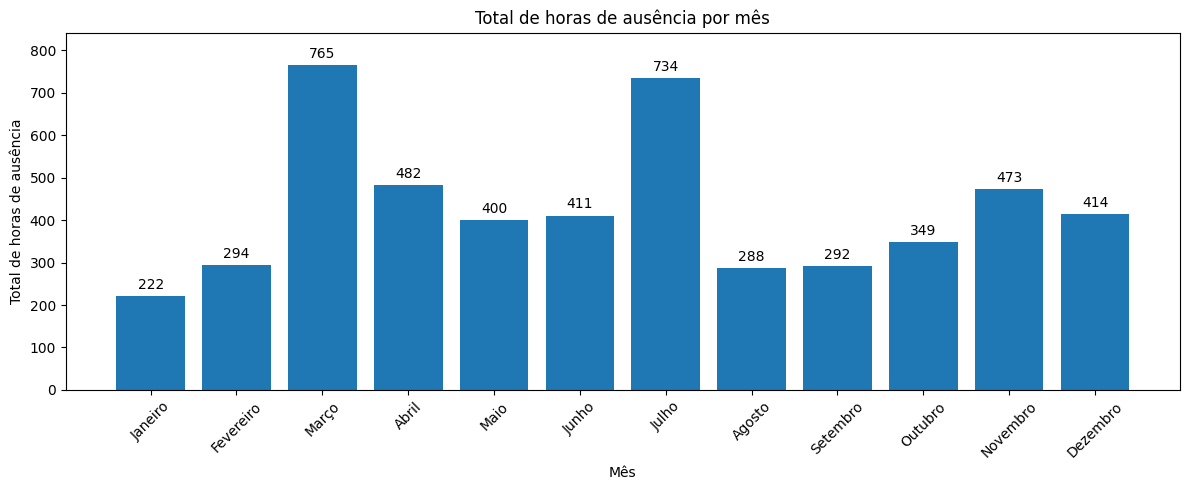

In [0]:
%python
import matplotlib.pyplot as plt

month_data = df_month_analysis.toPandas()

plt.figure(figsize=(12, 5))

bars = plt.bar(
    month_data["month_name"],
    month_data["total_absence_hours"]
)

plt.bar_label(
    bars,
    padding=3
)

plt.xlabel("Mês")
plt.ylabel("Total de horas de ausência")
plt.title("Total de horas de ausência por mês")

plt.xticks(rotation=45)
plt.margins(y=0.10)
plt.tight_layout()
plt.show()

In [0]:
%python
# ============================================
# 3. DISTRIBUIÇÃO DO ABSENTEÍSMO POR DIA DA SEMANA
# ============================================

df_weekday_analysis = (
    df_weekday
    .orderBy("day_of_week_code")
)

display(df_weekday_analysis)

day_of_week_code,day_of_week_name,absence_occurrences,total_absence_hours,average_absence_hours
2,Segunda-feira,161,1489,9.25
3,Terça-feira,154,1229,7.98
4,Quarta-feira,156,1115,7.15
5,Quinta-feira,125,553,4.42
6,Sexta-feira,144,738,5.13


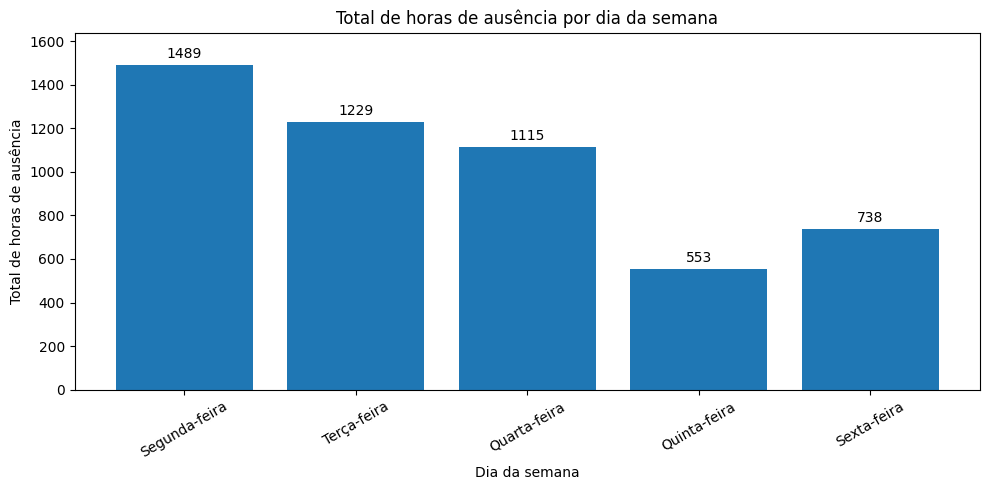

In [0]:
%python
weekday_data = df_weekday_analysis.toPandas()

plt.figure(figsize=(10, 5))

bars = plt.bar(
    weekday_data["day_of_week_name"],
    weekday_data["total_absence_hours"]
)

plt.bar_label(
    bars,
    padding=3
)

plt.xlabel("Dia da semana")
plt.ylabel("Total de horas de ausência")
plt.title("Total de horas de ausência por dia da semana")

plt.margins(y=0.10)
plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

In [0]:
%python
# ============================================
# 4. MOTIVOS DE AUSÊNCIA
# ============================================

df_reason_analysis = (
    df_reason
    .orderBy("total_absence_hours", ascending=False)
)

display(df_reason_analysis)

reason_code,reason_description,absence_occurrences,total_absence_hours,average_absence_hours
13,Doenças do sistema musculoesquelético e tecido conjuntivo,55,842,15.31
19,"Lesões, envenenamentos e consequências de causas externas",40,729,18.23
23,Consulta médica,149,424,2.85
28,Consulta odontológica,112,335,2.99
11,Doenças do sistema digestivo,26,297,11.42
22,Acompanhamento do paciente,38,293,7.71
10,Doenças do sistema respiratório,25,276,11.04
26,Ausência injustificada,33,240,7.27
18,"Sintomas, sinais e achados clínicos e laboratoriais",21,217,10.33
12,Doenças da pele e tecido subcutâneo,8,187,23.38


In [0]:
%python
# ============================================
# 4.1 MOTIVOS DE AUSÊNCIA MAIS FREQUENTES
# ============================================

df_reason_frequency = (
    df_reason
    .orderBy("absence_occurrences", ascending=False)
    .limit(10)
)

display(df_reason_frequency)

reason_code,reason_description,absence_occurrences,total_absence_hours,average_absence_hours
23,Consulta médica,149,424,2.85
28,Consulta odontológica,112,335,2.99
27,Fisioterapia,69,157,2.28
13,Doenças do sistema musculoesquelético e tecido conjuntivo,55,842,15.31
0,Não especificado na documentação,43,0,0.0
19,"Lesões, envenenamentos e consequências de causas externas",40,729,18.23
22,Acompanhamento do paciente,38,293,7.71
26,Ausência injustificada,33,240,7.27
25,Exame laboratorial,31,108,3.48
11,Doenças do sistema digestivo,26,297,11.42


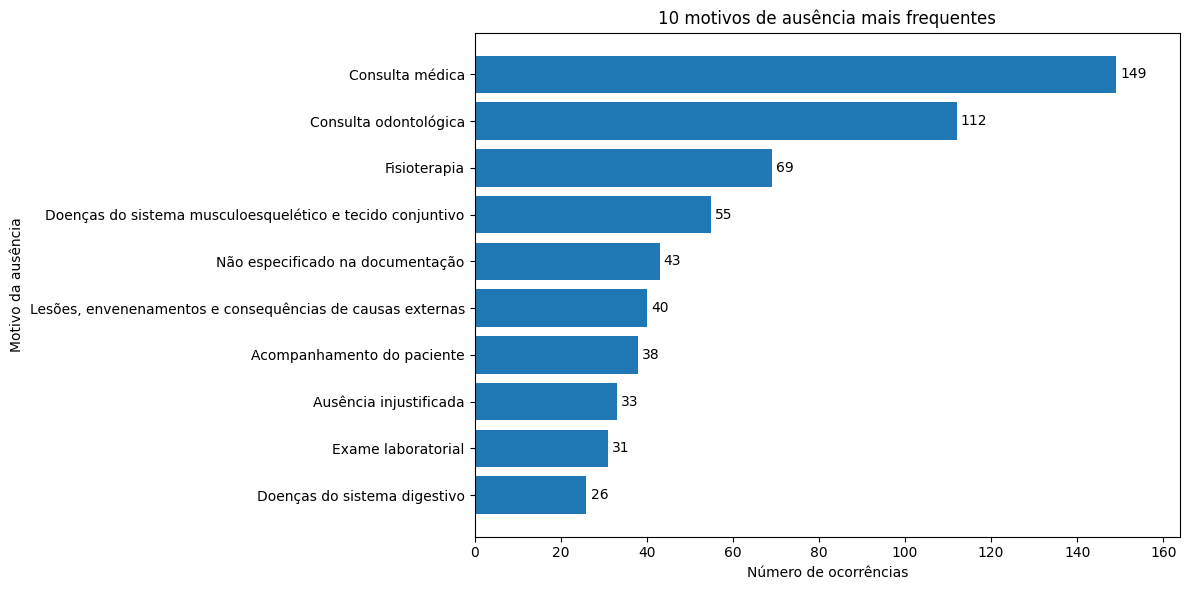

In [0]:
%python
reason_frequency_data = (
    df_reason_frequency
    .toPandas()
    .sort_values("absence_occurrences", ascending=True)
)

plt.figure(figsize=(12, 6))

bars = plt.barh(
    reason_frequency_data["reason_description"],
    reason_frequency_data["absence_occurrences"]
)

plt.bar_label(
    bars,
    padding=3
)

plt.xlabel("Número de ocorrências")
plt.ylabel("Motivo da ausência")
plt.title("10 motivos de ausência mais frequentes")

plt.margins(x=0.10)
plt.tight_layout()

plt.show()

In [0]:
%python
# ============================================
# 4.2 MOTIVOS COM MAIOR VOLUME DE HORAS
# ============================================

df_reason_hours = (
    df_reason
    .orderBy("total_absence_hours", ascending=False)
    .limit(10)
)

display(df_reason_hours)

reason_code,reason_description,absence_occurrences,total_absence_hours,average_absence_hours
13,Doenças do sistema musculoesquelético e tecido conjuntivo,55,842,15.31
19,"Lesões, envenenamentos e consequências de causas externas",40,729,18.23
23,Consulta médica,149,424,2.85
28,Consulta odontológica,112,335,2.99
11,Doenças do sistema digestivo,26,297,11.42
22,Acompanhamento do paciente,38,293,7.71
10,Doenças do sistema respiratório,25,276,11.04
26,Ausência injustificada,33,240,7.27
18,"Sintomas, sinais e achados clínicos e laboratoriais",21,217,10.33
12,Doenças da pele e tecido subcutâneo,8,187,23.38


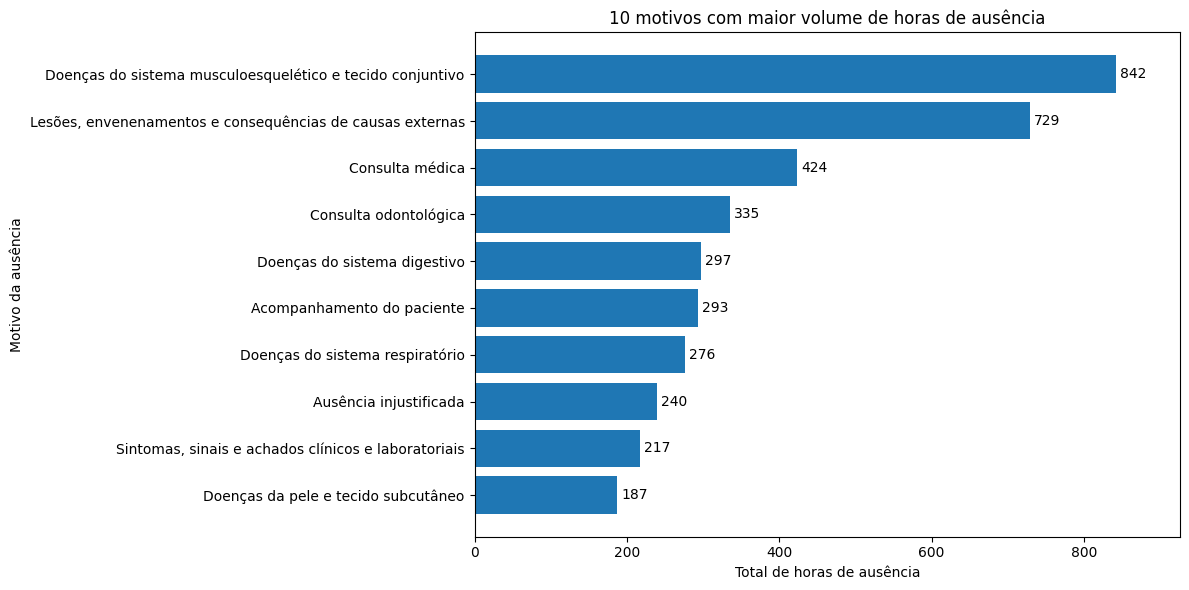

In [0]:
%python
reason_hours_data = (
    df_reason_hours
    .toPandas()
    .sort_values("total_absence_hours", ascending=True)
)

plt.figure(figsize=(12, 6))

bars = plt.barh(
    reason_hours_data["reason_description"],
    reason_hours_data["total_absence_hours"]
)

plt.bar_label(
    bars,
    padding=3
)

plt.xlabel("Total de horas de ausência")
plt.ylabel("Motivo da ausência")
plt.title("10 motivos com maior volume de horas de ausência")

plt.margins(x=0.10)
plt.tight_layout()

plt.show()

In [0]:
%python
# ============================================
# 5. CONCENTRAÇÃO DAS HORAS POR COLABORADOR
# ============================================

df_employee_analysis = (
    df_employee
    .orderBy("total_absence_hours", ascending=False)
)

display(df_employee_analysis)

id,absence_occurrences,total_absence_hours,average_absence_hours,percentage_total_hours
3,113,482,4.27,9.41
14,29,476,16.41,9.29
11,40,450,11.25,8.78
28,76,347,4.57,6.77
34,55,344,6.25,6.71
36,34,311,9.15,6.07
20,42,306,7.29,5.97
9,8,262,32.75,5.11
24,30,254,8.47,4.96
15,37,253,6.84,4.94


In [0]:
%python
# ============================================
# 5.1 PARTICIPAÇÃO DOS COLABORADORES COM MAIOR VOLUME DE HORAS
# ============================================

employee_data = df_employee_analysis.toPandas()

top_1 = employee_data.head(1)["percentage_total_hours"].sum()
top_3 = employee_data.head(3)["percentage_total_hours"].sum()
top_5 = employee_data.head(5)["percentage_total_hours"].sum()
top_10 = employee_data.head(10)["percentage_total_hours"].sum()

print(f"Top 1 colaborador: {top_1:.2f}% das horas")
print(f"Top 3 colaboradores: {top_3:.2f}% das horas")
print(f"Top 5 colaboradores: {top_5:.2f}% das horas")
print(f"Top 10 colaboradores: {top_10:.2f}% das horas")

Top 1 colaborador: 9.41% das horas
Top 3 colaboradores: 27.48% das horas
Top 5 colaboradores: 40.96% das horas
Top 10 colaboradores: 68.01% das horas


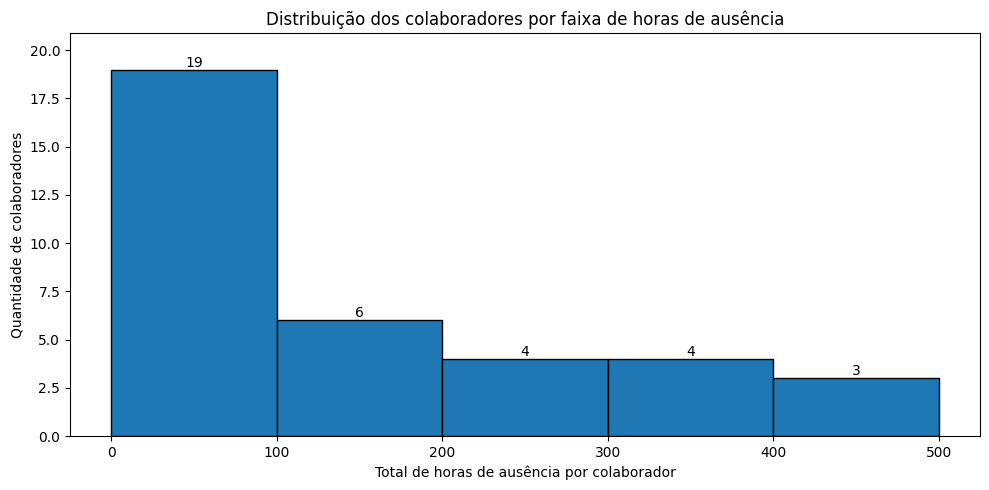

In [0]:
%python
# ============================================
# 5.2 DISTRIBUIÇÃO DOS COLABORADORES POR FAIXA DE HORAS
# ============================================

plt.figure(figsize=(10, 5))

counts, bins, patches = plt.hist(
    employee_data["total_absence_hours"],
    bins=[0, 100, 200, 300, 400, 500],
    edgecolor="black"
)

# Adiciona a quantidade de colaboradores sobre cada barra
for count, patch in zip(counts, patches):
    plt.text(
        patch.get_x() + patch.get_width() / 2,
        patch.get_height(),
        f"{int(count)}",
        ha="center",
        va="bottom"
    )

plt.xlabel("Total de horas de ausência por colaborador")
plt.ylabel("Quantidade de colaboradores")
plt.title("Distribuição dos colaboradores por faixa de horas de ausência")

plt.xticks([0, 100, 200, 300, 400, 500])
plt.margins(y=0.10)
plt.tight_layout()

plt.show()

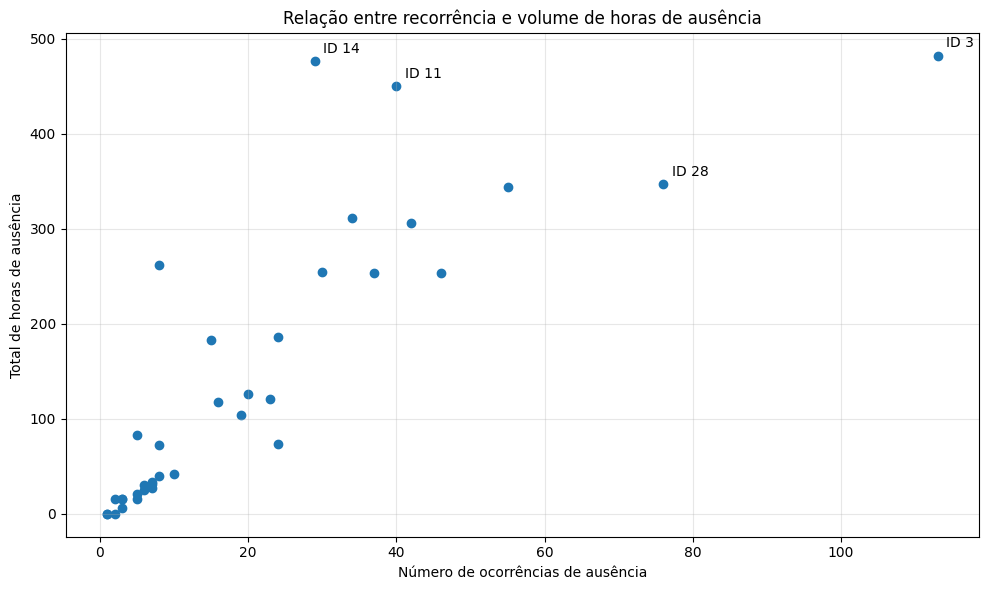

In [0]:
%python
# ============================================
# 6. RECORRÊNCIA X VOLUME DE HORAS
# ============================================

highlight_ids = [3, 14, 11, 28]

plt.figure(figsize=(10, 6))

plt.scatter(
    employee_data["absence_occurrences"],
    employee_data["total_absence_hours"]
)

for _, row in employee_data.iterrows():
    if row["id"] in highlight_ids:
        plt.annotate(
            f'ID {int(row["id"])}',
            (row["absence_occurrences"], row["total_absence_hours"]),
            xytext=(6, 6),
            textcoords="offset points"
        )

plt.xlabel("Número de ocorrências de ausência")
plt.ylabel("Total de horas de ausência")
plt.title("Relação entre recorrência e volume de horas de ausência")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [0]:
%python
# ============================================
# 6.1 CORRELAÇÃO ENTRE RECORRÊNCIA E VOLUME DE HORAS
# ============================================

correlation = employee_data[
    ["absence_occurrences", "total_absence_hours"]
].corr().iloc[0, 1]

print(
    f"Correlação entre número de ocorrências e "
    f"total de horas de ausência: {correlation:.3f}"
)

Correlação entre número de ocorrências e total de horas de ausência: 0.824


In [0]:
%python
# ============================================
# 7. ANÁLISE COMPLEMENTAR
# MOTIVOS DOS COLABORADORES COM MAIOR VOLUME
# ============================================

from pyspark.sql import functions as F

# Carrega os registros detalhados da camada Silver
df_silver = spark.table("workspace.silver.absenteeism")

# Identifica os 5 colaboradores com maior volume de horas
top_5_employees = (
    df_employee
    .orderBy(F.desc("total_absence_hours"))
    .limit(5)
    .select("id")
)

# Analisa os motivos de ausência desses colaboradores
df_top5_reasons = (
    df_silver
    .join(top_5_employees, on="id", how="inner")
    .groupBy(
        "id",
        "reason_code",
        "reason_description"
    )
    .agg(
        F.count("*").alias("absence_occurrences"),
        F.sum("absenteeism_time_in_hours").alias("total_absence_hours")
    )
    .orderBy(
        "id",
        F.desc("total_absence_hours")
    )
)

display(df_top5_reasons)

id,reason_code,reason_description,absence_occurrences,total_absence_hours
3,13,Doenças do sistema musculoesquelético e tecido conjuntivo,10,131
3,28,Consulta odontológica,26,101
3,27,Fisioterapia,38,97
3,23,Consulta médica,19,54
3,11,Doenças do sistema digestivo,7,29
3,18,"Sintomas, sinais e achados clínicos e laboratoriais",2,16
3,10,Doenças do sistema respiratório,2,12
3,21,Fatores que influenciam o estado de saúde,2,9
3,6,Doenças do sistema nervoso,1,8
3,26,Ausência injustificada,1,8


In [0]:
%python
# ============================================
# 7.1 PRINCIPAL MOTIVO EM HORAS DOS TOP 5 COLABORADORES
# ============================================

from pyspark.sql.window import Window

window_employee = (
    Window
    .partitionBy("id")
    .orderBy(F.desc("total_absence_hours"))
)

df_top5_main_reason = (
    df_top5_reasons
    .withColumn(
        "rank",
        F.row_number().over(window_employee)
    )
    .filter(F.col("rank") == 1)
    .drop("rank")
    .orderBy(F.desc("total_absence_hours"))
)

display(df_top5_main_reason)

id,reason_code,reason_description,absence_occurrences,total_absence_hours
11,19,"Lesões, envenenamentos e consequências de causas externas",8,208
34,19,"Lesões, envenenamentos e consequências de causas externas",4,153
3,13,Doenças do sistema musculoesquelético e tecido conjuntivo,10,131
14,11,Doenças do sistema digestivo,1,120
28,9,Doenças do sistema circulatório,1,112
